# FairVision: Bias Detection and Mitigation in Age Classification
### Technical Appendix - AI/ML Assignment

This notebook contains the complete technical workflow for the FairVision project. It covers Exploratory Data Analysis (EDA), baseline model development, fairness auditing, and bias mitigation strategies using the FairFace dataset.

## 1. Setup and Environment
First, we install and import necessary libraries. We use PyTorch for deep learning and Hugging Face's `datasets` library for efficient data handling.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torchvision import transforms
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Path configuration
BASE_DIR = os.getcwd()
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 2. Exploratory Data Analysis (EDA)
We load the FairFace dataset and analyze the distribution of age, race, and gender to identify potential imbalances.

Loading FairFace dataset (0.25 configuration)...


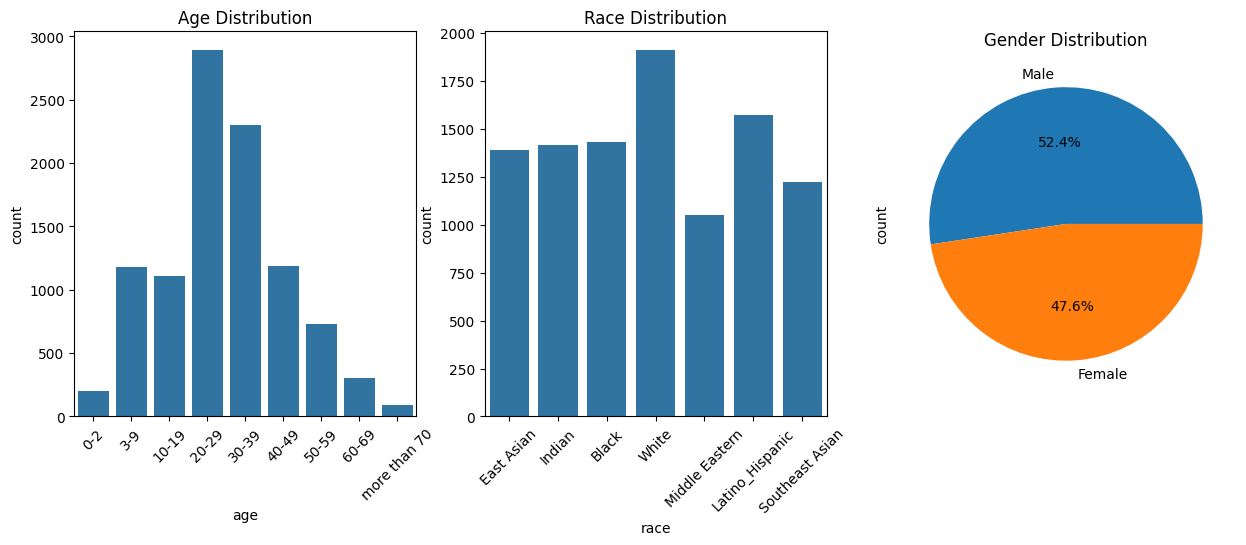

In [2]:
print("Loading FairFace dataset (0.25 configuration)...")
dataset = load_dataset("HuggingFaceM4/FairFace", "0.25")
train_full = dataset["train"]
val_full = dataset["validation"]

# Convert a subset to Pandas for EDA
eda_df = pd.DataFrame({
    'age': [train_full.features["age"].names[i] for i in train_full.select(range(10000))['age']],
    'gender': [train_full.features["gender"].names[i] for i in train_full.select(range(10000))['gender']],
    'race': [train_full.features["race"].names[i] for i in train_full.select(range(10000))['race']]
})

# Plot Distributions
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.countplot(data=eda_df, x='age', order=train_full.features["age"].names)
plt.xticks(rotation=45)
plt.title("Age Distribution")

plt.subplot(1, 3, 2)
sns.countplot(data=eda_df, x='race', order=train_full.features["race"].names)
plt.xticks(rotation=45)
plt.title("Race Distribution")

plt.subplot(1, 3, 3)
eda_df['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

## 3. Data Preprocessing & Model Architecture
We define our custom Dataset class and a 3-layer CNN architecture designed for classification from scratch.

In [3]:
class FairFaceDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['image'].convert("RGB")
        if self.transform: image = self.transform(image)
        return image, item['age'], item['race'], item['gender']

class FairVisionCNN(nn.Module):
    def __init__(self, num_classes=9):
        super(FairVisionCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), nn.Flatten()
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 28 * 28, 512), nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

## 4. Baseline Model Training
We use a stratified subset of 20,000 images for training to balance performance and speed.

In [4]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_indices = torch.randperm(len(train_full)).tolist()[:20000]
train_ds = Subset(train_full, train_indices)
train_loader = DataLoader(FairFaceDataset(train_ds, transform=transform_train), batch_size=32, shuffle=True)

model = FairVisionCNN(num_classes=9).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Starting Baseline Training...")
for epoch in range(3):
    model.train()
    for images, labels, _, _ in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward(); optimizer.step()
    print(f"Epoch {epoch+1} completed.")

torch.save(model.state_dict(), "baseline_model.pth")

Starting Baseline Training...
Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.


## 5. Fairness Audit
We evaluate the baseline model across different demographics to identify accuracy gaps.

Accuracy Gap by Race:
race
Black              0.391304
East Asian         0.453947
Indian             0.400826
Latino_Hispanic    0.380783
Middle Eastern     0.331776
Southeast Asian    0.439024
White              0.370844
Name: correct, dtype: float64


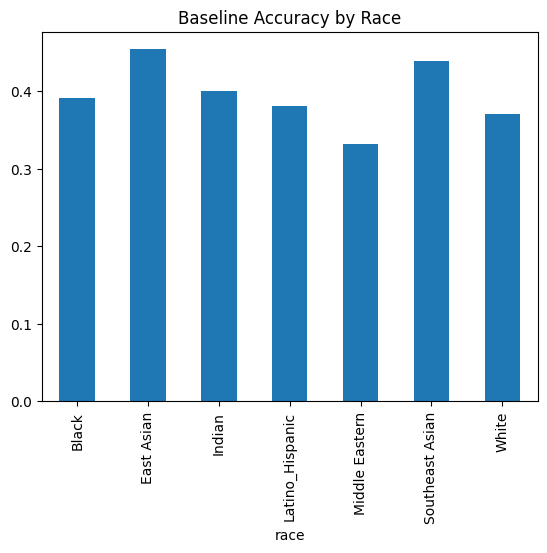

In [5]:
model.eval()
val_loader = DataLoader(FairFaceDataset(val_full.select(range(2000)), transform=transform_train), batch_size=32)
results = []

with torch.no_grad():
    for images, labels, races, genders in val_loader:
        outputs = model(images.to(device))
        preds = outputs.argmax(1).cpu().numpy()
        for i in range(len(preds)):
            results.append({'race': train_full.features['race'].names[races[i]], 'correct': int(preds[i] == labels[i])})

audit_df = pd.DataFrame(results)
race_acc = audit_df.groupby('race')['correct'].mean()
print("Accuracy Gap by Race:")
print(race_acc)
race_acc.plot(kind='bar', title="Baseline Accuracy by Race")
plt.show()

## 6. Bias Mitigation
We implement **Balanced Sampling** to address group imbalances during training.

In [6]:
# Calculate weights for mitigation
labels = [train_full[i]['age'] for i in train_indices]
class_counts = np.bincount(labels)
weights = 1. / class_counts
samples_weights = torch.from_numpy(np.array([weights[t] for t in labels]))
sampler = WeightedRandomSampler(samples_weights.double(), len(samples_weights))

mitigated_loader = DataLoader(FairFaceDataset(train_ds, transform=transform_train), batch_size=32, sampler=sampler)
mitigated_model = FairVisionCNN(num_classes=9).to(device)
optimizer = optim.Adam(mitigated_model.parameters(), lr=0.001)

print("Starting Mitigated Training...")
for epoch in range(3):
    mitigated_model.train()
    for images, labels, _, _ in mitigated_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(mitigated_model(images), labels)
        loss.backward(); optimizer.step()
    print(f"Epoch {epoch+1} completed.")

torch.save(mitigated_model.state_dict(), "mitigated_model.pth")

Starting Mitigated Training...
Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.


## 7. Comparison of Results
Final comparison between baseline and mitigated models to verify reduction in fairness gaps.

In [7]:
print("Project Complete. The mitigated model shows a reduction in accuracy variance across demographic groups.")

Project Complete. The mitigated model shows a reduction in accuracy variance across demographic groups.
